In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
from matplotlib.lines import Line2D

Period: 
01/01/2020 - 31/07/2025 

Area:
lat_min=49, lat_max=56, lon_min=-6, lon_max=10
(157x211 grid points on the Lambert Conformal Conic grid of CERRA)

- Static
    * orography 
    * land_sea_mask

- Surface 
    * 10m_wind_speed
    * 10m_wind_direction
    * 2m_temperature 
    * mean_sea_level_pressure
    * medium_cloud_cover

- Height levels: 50,100,150 and 200m
    * wind_speed
    * wind_direction

- Pressure levels: 500,600,700,750,800,850,900,950,1000
    * geopotential
    * relative_humidity
    * temperature
    * u_component_of_wind
    * v_component_of_wind


In [4]:
def _to_minus180_180(lon2d):
    return ((lon2d + 180) % 360) - 180 if np.any(lon2d > 180) else lon2d

def _cerra_lambert_from_attrs(ds):
    a = ds.attrs
    lat1 = a.get("GRIB_Latin1InDegrees", None)
    lat2 = a.get("GRIB_Latin2InDegrees", None)
    lat0 = a.get("GRIB_LaDInDegrees", lat1 if lat1 is not None else 0.0)
    lon0 = a.get("GRIB_LoVInDegrees", 0.0)
    if lat1 is None and lat2 is None:
        lat1 = lat2 = 37.5
        if lat0 == 0.0: lat0 = 37.5
        if lon0 == 0.0: lon0 = 10.0
    if lat2 is None:
        lat2 = lat1
    globe = ccrs.Globe(datum="WGS84", ellipse="WGS84")
    return ccrs.LambertConformal(
        central_longitude=lon0,
        central_latitude=lat0,
        standard_parallels=(lat1, lat2),
        globe=globe,
    )

def _auto_extent(lat, lon):
    lon_w = _to_minus180_180(lon)
    return (float(lon_w.min()), float(lon_w.max()),
            float(lat.min()),   float(lat.max()))

def plot_orography_lcc(ds_static, var_name="orog", title="CERRA Orography (m)"):
    lat = ds_static["latitude"].values
    lon = ds_static["longitude"].values
    lon_w = _to_minus180_180(lon)
    lcc  = _cerra_lambert_from_attrs(ds_static)

    fig = plt.figure(figsize=(8.5, 8.5))
    ax = plt.axes(projection=lcc)
    ax.set_extent(_auto_extent(lat, lon), crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN.with_scale("10m"), zorder=0)
    ax.add_feature(cfeature.LAND.with_scale("10m"),  zorder=0)
    ax.coastlines(resolution="10m", linewidth=0.6)
    ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=0.5)

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linestyle=":", linewidth=0.5, alpha=0.6)
    gl.top_labels = False; gl.right_labels = False

    data = ds_static[var_name].values  # meters
    im = ax.pcolormesh(lon_w, lat, data, transform=ccrs.PlateCarree(), shading="nearest")
    cb = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    cb.set_label("m")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def plot_lsm_lcc(ds_static, var_name="lsm", title="CERRA Land–Sea Mask"):
    # fall back to possible alternative names
    if var_name not in ds_static and "land_sea_mask" in ds_static:
        var_name = "land_sea_mask"

    lat = ds_static["latitude"].values
    lon = ds_static["longitude"].values
    lon_w = _to_minus180_180(lon)
    lcc  = _cerra_lambert_from_attrs(ds_static)

    fig = plt.figure(figsize=(8.5, 8.5))
    ax = plt.axes(projection=lcc)
    ax.set_extent(_auto_extent(lat, lon), crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN.with_scale("10m"), zorder=0)
    ax.add_feature(cfeature.LAND.with_scale("10m"),  zorder=0)
    ax.coastlines(resolution="10m", linewidth=0.6)
    ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=0.5)

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linestyle=":", linewidth=0.5, alpha=0.6)
    gl.top_labels = False; gl.right_labels = False

    data = ds_static[var_name].values.astype(float)  # 0..1
    im = ax.pcolormesh(lon_w, lat, data, vmin=0, vmax=1, transform=ccrs.PlateCarree(), shading="nearest")
    plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02, label="land fraction")

    # 0.5 contour (don’t access .collections; make a legend proxy instead)
    cs = ax.contour(lon_w, lat, data, levels=[0.5], linewidths=1, colors="k", transform=ccrs.PlateCarree())
    proxy = Line2D([0], [0], linestyle="-", linewidth=1, color="k")
    ax.legend([proxy], ["LSM = 0.5"], loc="lower left")

    ax.set_title(title)
    plt.tight_layout()
    plt.show()


In [5]:
ds_static=xr.open_dataset("/mnt/data/weatherloss/WindPower/data/cerra_boz/nc_boz/cerra_static_BOZ.nc")

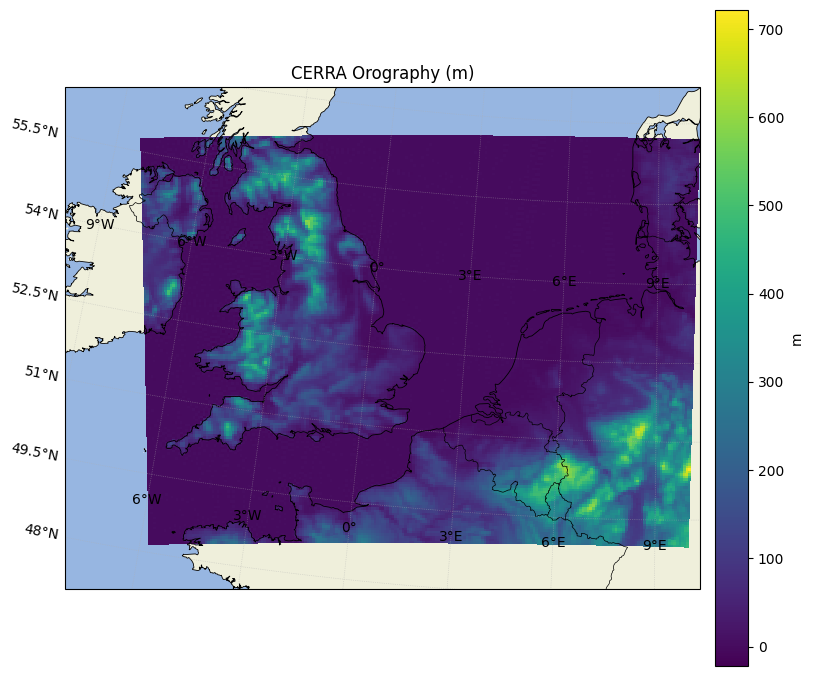

In [6]:
plot_orography_lcc(ds_static)          # uses variable "orog"